Task 2 Level 1

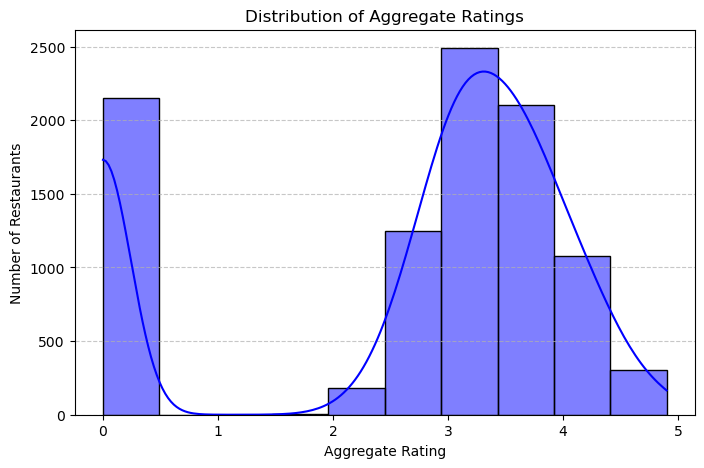

{'Most Common Rating': 0.0, 'Average Number of Votes': 156.909747670401}


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("C:/Users/Rajguru/Downloads/Dataset  (1).csv")

# Plot the distribution of aggregate ratings
plt.figure(figsize=(8, 5))
sns.histplot(data['Aggregate rating'], bins=10, kde=True, color='blue')
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")
plt.title("Distribution of Aggregate Ratings")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Determine the most common rating range
rating_counts = data['Aggregate rating'].value_counts().sort_index()
most_common_rating = rating_counts.idxmax()

# Calculate the average number of votes received by restaurants
average_votes = data['Votes'].mean()

# Store the results
rating_analysis = {
    "Most Common Rating": most_common_rating,
    "Average Number of Votes": average_votes
}

print(rating_analysis)


Task 2 Level 2

In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv("C:/Users/Rajguru/Downloads/Dataset  (1).csv")

# Count the most common cuisine combinations
cuisine_combinations = data['Cuisines'].dropna().value_counts()

# Get the top 5 most common cuisine combinations
top_cuisine_combinations = cuisine_combinations.head(5)

# Analyze the average ratings for different cuisine combinations
cuisine_combination_ratings = data.groupby('Cuisines')['Aggregate rating'].mean().sort_values(ascending=False)

# Get the top 5 cuisine combinations with the highest average ratings
top_rated_cuisine_combinations = cuisine_combination_ratings.head(5)

# Store results in DataFrames
top_cuisine_combinations_df = pd.DataFrame({
    'Cuisine Combination': top_cuisine_combinations.index,
    'Count': top_cuisine_combinations.values
})

top_rated_cuisine_combinations_df = pd.DataFrame({
    'Cuisine Combination': top_rated_cuisine_combinations.index,
    'Average Rating': top_rated_cuisine_combinations.values
})

print("Most Common Cuisine Combinations:\n", top_cuisine_combinations_df)
print("\nHighest Rated Cuisine Combinations:\n", top_rated_cuisine_combinations_df)


Most Common Cuisine Combinations:
      Cuisine Combination  Count
0           North Indian    936
1  North Indian, Chinese    511
2                Chinese    354
3              Fast Food    354
4  North Indian, Mughlai    334

Highest Rated Cuisine Combinations:
        Cuisine Combination  Average Rating
0            Italian, Deli             4.9
1        Hawaiian, Seafood             4.9
2  American, Sandwich, Tea             4.9
3      Continental, Indian             4.9
4  European, Asian, Indian             4.9


Task 2 Level 3

In [4]:
import folium
from folium.plugins import MarkerCluster
import pandas as pd

# Load dataset
data = pd.read_csv("C:/Users/Rajguru/Downloads/Dataset  (1).csv")

# Ensure longitude and latitude are numeric
data['Longitude'] = pd.to_numeric(data['Longitude'], errors='coerce')
data['Latitude'] = pd.to_numeric(data['Latitude'], errors='coerce')
data = data.dropna(subset=['Longitude', 'Latitude'])  # Remove missing values

# Create a map centered at the average location
average_lat = data['Latitude'].mean()
average_long = data['Longitude'].mean()
restaurant_map = folium.Map(location=[average_lat, average_long], zoom_start=12)

# Add marker clusters
marker_cluster = MarkerCluster().add_to(restaurant_map)

# Add restaurant locations to the map
for _, row in data.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Restaurant: {row['Restaurant Name']}<br>Rating: {row['Aggregate rating']}",
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(marker_cluster)

# Save the map
restaurant_map.save("restaurant_locations_map.html")


Task 2 level 4

In [5]:
import pandas as pd

# Load the dataset
data = pd.read_csv("C:/Users/Rajguru/Downloads/Dataset  (1).csv")
# Count the number of occurrences of each restaurant name
restaurant_chain_counts = data['Restaurant Name'].value_counts()

# Identify restaurant chains (restaurants appearing more than once)
restaurant_chains = restaurant_chain_counts[restaurant_chain_counts > 1]

# Analyze the average rating and popularity (votes) of restaurant chains
restaurant_chain_analysis = data[data['Restaurant Name'].isin(restaurant_chains.index)].groupby('Restaurant Name').agg(
    Average_Rating=('Aggregate rating', 'mean'),
    Total_Votes=('Votes', 'sum'),
    Number_of_Locations=('Restaurant Name', 'count')
).sort_values(by='Number_of_Locations', ascending=False)

# Display the top 5 restaurant chains
print(restaurant_chain_analysis.head(5))


                  Average_Rating  Total_Votes  Number_of_Locations
Restaurant Name                                                   
Cafe Coffee Day         2.419277         2428                   83
Domino's Pizza          2.740506         6643                   79
Subway                  2.907937         6124                   63
Green Chick Chop        2.672549          964                   51
McDonald's              3.339583         5291                   48
